# Thermal Via Optimization for Voltage Regulators
### Probabilistic Design Optimization Final Project

**Author:** Kuhu Jayaswal
**Date:** 22nd April, 2026

# 1. Executive Summary

Hardware designers placing voltage regulator ICs on PCBs face a recurring question: how many thermal vias are needed under the chip's thermal pad to keep the junction temperature below the datasheet limit? Too few vias risks overheating; too many wastes board area and complicates routing. Industry practice is to guess based on rules of thumb. This project replaces that guess with a probabilistic design optimization that accounts for real-world variation in load current, ambient temperature, and via plating thickness manufacturing tolerance. We compare three common regulators (AP2112K-3.3 small LDO, AMS1117-3.3 classic LDO, TPS5430 switching regulator) across two power scenarios: 5V USB-powered and 12V adapter-powered, both producing 3.3V at 500 mA. The methodology combines a grama-based reliability model, Monte Carlo evaluation, multi-start constrained optimization, and a three-objective Pareto comparison across via count, reliability, BOM cost. 

The key finding: at 5V, the cheap AMS1117 with 1–3 thermal vias is a cost-efficient feasible choice. At 12V, both LDOs are infeasible regardless of via count, leaving the switching regulator as the only viable option. The general design rule that emerges: for input-to-output voltage drops above ~3V at meaningful current, designers should switch topologies rather than fight thermal margin with via arrays.

# 2. Background

## 2.1 Project context

A voltage regulator on a PCB generates heat. If that heat cannot escape, the chip's junction temperature climbs above the datasheet maximum, causing thermal shutdown, accelerated aging, or outright failure. The standard escape path is a grid of **thermal vias**: small plated holes under the chip's thermal pad that conduct heat to a copper plane on the opposite layer of the board, where it spreads out and convects to ambient air.

The number of thermal vias is a design decision that materially affects reliability, yet is typically under-specified in datasheets. Datasheet reference layouts often assume favorable copper pour areas that real designs may not have. Hobbyist and many commercial boards are routinely under-via'd, leading to thermal failures in the field that are hard to diagnose and easy to prevent at design time.

## 2.2 Stakeholders and their needs

**Primary stakeholder: hardware design engineer**
A hardware engineer designing a small product (an MCU board, an IoT device, a sensor module) needs to choose a voltage regulator and decide on the thermal via array under it. They want:
- to meet the chip's junction-temperature limit under the actual operating conditions of the product, not just typical datasheet conditions,
- a defensible via count they can justify in design review without copying a reference layout that may not apply,
- minimal board area committed to thermal management so other components can be routed,
- low BOM cost.

**Secondary stakeholder: end user of the finished product**
The end user does not see the regulator design but bears its consequences. Under-designed thermal management causes:
- intermittent product faults under sustained load,
- shortened product lifetime due to accelerated thermal aging,
- safety risks in worst-case overheating scenarios,
- e-waste from products that fail prematurely.

## 2.3 The three regulators compared

Three regulators that represent three common ways designers solve a "I need a 3.3V rail" problem.

**Variables used in the table below:**
- **θJC (junction-to-case thermal resistance, °C/W):** how hard it is for heat to escape from the silicon die to the bottom of the package. Lower is better. Set by the chip's internal construction; the designer cannot change it.
- **θJA bare (junction-to-ambient thermal resistance, °C/W):** how hard it is for heat to escape from the silicon die all the way out to the surrounding air, with no thermal vias and minimal copper pour. Lower is better. This is what we are trying to improve by adding thermal vias.
- **Tj_max (maximum junction temperature, °C):** the datasheet's upper limit on chip temperature. Above this, the chip throttles, shuts down, or fails. Failure in this project is defined as Tj > Tj_max.
- **BOM cost:** approximate single-unit cost in USD, including any external components (the switcher needs an inductor and extra caps; the LDOs do not).

| | AP2112K-3.3 | AMS1117-3.3 | TPS5430 |
|---|---|---|---|
| **Type** | LDO (linear regulator) | LDO (linear regulator) | Switching regulator (buck converter) |
| **Package** | SOT-23-5 (tiny 5-pin SMT) | SOT-223 (SMT with thermal tab) | HSOIC-8 with central PowerPAD |
| **Thermal pad present?** | No | Yes (the SOT-223 tab itself) | Yes (exposed pad on bottom) |
| **θJC, junction-to-case (°C/W)** | ~90 (high; no pad) | 15 (low) | 2 (very low) |
| **θJA bare, junction-to-ambient (°C/W)** | 184 (very high) | ~83 | ~40 |
| **Tj_max, max junction temp (°C)** | 150 | 125 | 125 |
| **Efficiency** | LDO; not applicable | LDO; not applicable | ~90% (buck switcher) |
| **Approx BOM cost (USD)** | \$0.20 (IC only) | \$0.05 (IC only) | \$3.50 (IC + inductor + caps) |
| **Typical use case** | Small low-current rails on hobbyist boards | Cheap medium-current rails (the "Amazon module" regulator) | Higher current, or high input voltages where an LDO would dissipate too much heat |

**Interpretation:**
- **AP2112K-3.3** has the worst θJA because the SOT-23-5 package has no thermal pad: heat can only leave through five small pins. Thermal vias barely help because there is no good thermal path *into* the via array.
- **AMS1117-3.3** has a metal tab on its underside that serves as a thermal pad. Thermal vias under that tab significantly reduce the case-to-ambient resistance.
- **TPS5430** has a dedicated central thermal pad designed for via stitching, and (more importantly) is a switching regulator that dissipates ~10× less heat than an LDO would for the same load. The combination makes it nearly trivial to thermally manage.

## 2.4 The two scenarios analyzed

**Scenario 1: 5V USB-powered product.** A consumer or IoT device powered from USB (5V), needing a 3.3V rail at 500 mA for its MCU and peripherals. The voltage drop across the regulator is 1.7V; for an LDO, dissipation is 0.85W. Moderate thermal stress.

**Scenario 2: 12V adapter-powered product.** An industrial sensor, automotive accessory, or wall-adapter-powered device, taking 12V in and producing the same 3.3V at 500 mA rail. Voltage drop is 8.7V; for an LDO, dissipation is 4.35W. Severe thermal stress.

Together, the two scenarios span a wide range of realistic products and reveal a design rule: switching regulators become essential at higher input voltages.

# 3. Tenchi Diagram

The Tenchi Diagram defines the system boundary of the analysis: which natural-world phenomena are represented by the model, what's an input vs. an output, what's a design variable vs. an uncertainty vs. a parameter, and what assumptions and limitations bound the model's validity.

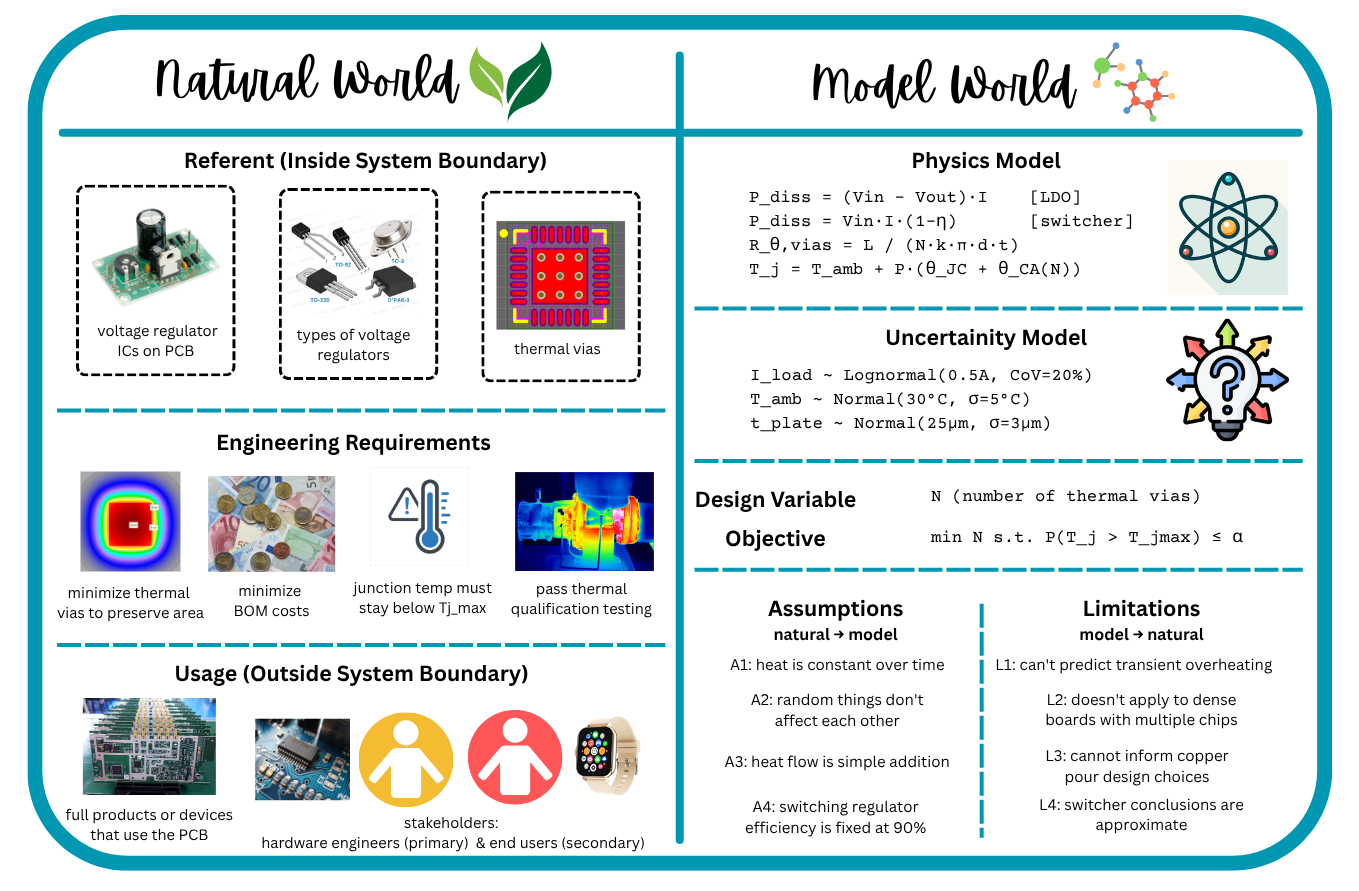

## 3.1 Inputs and outputs

**Inputs**
- Design variable: `n_vias` (integer count of thermal vias, treated as continuous in [1, 50] for optimization)
- Uncertainty 1: `I_load` (load current in A, lognormal)
- Uncertainty 2: `T_amb` (ambient temperature in °C, normal)
- Uncertainty 3: `t_plate` (via barrel plating thickness in μm, normal)
- Parameters: V_in, V_out, regulator datasheet values (θJC, θCA_base, via_effectiveness, Tj_max, efficiency for switchers), via geometry constants (drill diameter, board thickness, copper conductivity)

**Outputs**
- `T_j` (predicted junction temperature, °C)
- Derived: `pof` (probability that T_j > Tj_max), `n_min` (smallest feasible N), BOM cost per design

## 3.2 Functions linking inputs to outputs

1. Power dissipated: `P = (V_in - V_out) * I_load` for LDO, or `P = V_in * I_load * (1 - η)` for switcher.
2. Via array thermal resistance: `R_θ_vias = L_via / (N · k_cu · π · d_drill · t_plate)` (parallel via cylinders).
3. Effective case-to-ambient resistance: `θ_CA_effective(N) = θ_CA_unhelped + (θ_CA_helped ∥ R_θ_vias)`. Vias are placed in parallel with the helpable fraction of the path; the unhelpable fraction (e.g., package-top radiation) is unchanged. More vias → smaller `R_θ_vias` → smaller `θ_CA_effective(N)` → lower `T_j`.
4. Junction temperature: `T_j = T_amb + P · (θ_JC + θ_CA_effective(N))`.

## 3.3 Assumptions (≥ 3 required)

The diagram lists four assumptions, restated here with their technical names:

1. **A1: Heat is constant over time (steady-state thermal).** Transient current spikes are not modeled; we assume the regulator operates at a roughly constant load over time periods long enough for thermal equilibrium to be reached.
2. **A2: Random inputs are independent of each other (independent uncertainties).** Load current, ambient temperature, and via plating tolerance are modeled as statistically independent. In practice, load and ambient may be weakly correlated, but the effect is small relative to the dominant load-current variability.
3. **A3: Heat flow is simple addition (linear thermal superposition).** The case-to-ambient path is modeled as two series-parallel resistance terms; we ignore higher-order effects of via-to-via thermal coupling and finite spreading-resistance saturation at large N.
4. **A4: Switching efficiency is a fixed 90%.** The TPS5430's efficiency is taken as 90% across its operating range, even though it actually varies with V_in and load.

## 3.4 Limitations (≥ 3 required)

Each limitation arises from one or more of the assumptions above:

1. **L1: Can't predict transient overheating** *(arises from A1).* Because we assumed steady-state, the model cannot catch short bursts of high current that briefly spike the junction temperature. Real products with bursty load patterns may need additional thermal margin beyond what our model recommends.
2. **L2: Doesn't apply to dense boards with multiple heat sources** *(arises from A2).* Treating uncertainties as independent and modeling only a single regulator means the model cannot capture mutual heating between adjacent components on densely packed boards. The analysis is appropriate for sparse layouts but not for tightly integrated power-stage subsystems.
3. **L3: Cannot inform copper pour design choices** *(arises from A3).* Since  the model can’t distinguish copper‑pour geometries, it can’t advise on pour area, void placement, or interactions with vias. Designers still need thermal FEA or empirical testing to make those layout decisions.
4. **L4: Switcher conclusions are approximate** *(arises from A4).* Because efficiency was held fixed at 90%, predicted heat dissipation for the TPS5430 may deviate from reality at unusual operating points (very low load or high V_in extremes).

# 4. Formulation

## 4.1 Standard-form optimization problem


For each (regulator, scenario) pair, we solve the reliability-based design optimization problem:

$$
\begin{aligned}
\min_{N} \quad & N \\[12pt]
\text{s.t.} \quad & \Pr\left( T_j(N,\ I_{\text{load}},\ T_{\text{amb}},\ t_{\text{plate}}) > T_{j,\max} \right) \le \alpha \\[6pt]
& 1 \le N \le 50
\end{aligned}
$$

where:
- $N$ is the number of thermal vias (design variable)
- $T_j$ is the junction temperature (output of the physics model)
- $T_{j,\max}$ is the datasheet maximum junction temperature for the part
- $\alpha = 0.01$ is the target maximum probability of overheating
- $I_{load}, T_{amb}, t_{plate}$ are the three uncertain inputs

The three-objective extension (Section 5.3.2 below) treats `(N, P_fail, cost)` as competing objectives and looks at Pareto-optimal regulator choices across them.

## 4.2 Probability model

Three independent uncertainty sources, with their distributions:

| Variable | Distribution | Parameters | Justification |
|---|---|---|---|
| `I_load` | Lognormal | mean = 500 mA, CoV = 20% | User behavior varies; lognormal is positive and right-skewed |
| `T_amb` | Normal | mean = 30°C, std = 5°C | Indoor enclosure temperature variation |
| `t_plate` | Normal | mean = 25 μm, std = 3 μm | Standard fab tolerance on via barrel plating |

These propagate through the physics model to produce a distribution of `T_j` for any given N.


**Why normal distributions are acceptable here.** A normal can return negative values, but for our parameters: $\Pr(T_{amb} < 0) = \Phi(-6) \approx 10^{-9}$ and $\Pr(t_{plate} < 0) \approx \Phi(-8.3) \approx 5 \times 10^{-17}$. Both are far below $10^{-6}$, so nonphysical realizations are negligible.

**Why independence is reasonable.** `I_load` is set by user behavior, `T_amb` by the room, `t_plate` by the PCB fab months earlier. The mechanisms are physically unrelated. A second-order coupling between load and ambient (self-heating of the enclosure) exists but is small at our power levels (≤ 4.35 W) relative to the 5°C room-to-room std dev.

## 4.3 Setup

In [1]:
import grama as gr
import numpy as np
import pandas as pd

DF = gr.Intention()
%matplotlib inline

## 4.4 Constants

These are the Tenchi-diagram parameters: fixed numbers used everywhere.

In [2]:
# Design target 
V_OUT_TARGET_V          = 3.3       # output rail voltage (V)
LOAD_CURRENT_NOMINAL_A  = 0.500     # nominal load current (A)
RELIABILITY_TARGET      = 0.01      # we want P(overheat) <= 1%

# Via geometry (standard 2-layer FR-4 fab) 
VIA_DRILL_DIAMETER_MM       = 0.3     # via drill size (mm)
BOARD_THICKNESS_MM          = 1.6     # board thickness (mm)
COPPER_CONDUCTIVITY_W_PER_MK = 400.0  # thermal conductivity of copper (W/m·K)

# Uncertainty distribution parameters 
LOAD_CURRENT_COV         = 0.20    # coefficient of variation on I_load
AMBIENT_TEMP_MEAN_C      = 30.0    # mean ambient (°C)
AMBIENT_TEMP_STD_C       = 5.0     # std of ambient (°C)
VIA_PLATING_NOMINAL_UM   = 25.0    # nominal plating thickness (μm)
VIA_PLATING_STD_UM       = 3.0     # plating tolerance (μm)

## 4.5 Regulator parameters

Each regulator is a dictionary of datasheet-derived values plus an empirical `via_effectiveness` constant.

In [3]:
regulator_AP2112_small_LDO = dict(
    name              = "AP2112K-3.3",
    kind              = "ldo",
    theta_JC_CperW    = 90.0,
    theta_CA_base_CperW = 94.0,
    via_effectiveness = 0.05,        # no thermal pad; vias barely help
    Tj_max_C          = 150.0,
    efficiency        = None,
    cost_usd          = 0.20,
)

regulator_AMS1117_classic_LDO = dict(
    name              = "AMS1117-3.3",
    kind              = "ldo",
    theta_JC_CperW    = 15.0,
    theta_CA_base_CperW = 68.0,      # conservative, derived from datasheet max-power spec
    via_effectiveness = 0.80,        # thermal tab; vias help a lot
    Tj_max_C          = 125.0,
    efficiency        = None,
    cost_usd          = 0.05,
)

regulator_TPS5430_buck_switcher = dict(
    name              = "TPS5430",
    kind              = "switcher",
    theta_JC_CperW    = 2.0,
    theta_CA_base_CperW = 38.0,
    via_effectiveness = 0.85,
    Tj_max_C          = 125.0,
    efficiency        = 0.90,        # ~90% efficient at typical operating point
    cost_usd          = 3.50,
)

ALL_REGULATORS = [
    regulator_AP2112_small_LDO,
    regulator_AMS1117_classic_LDO,
    regulator_TPS5430_buck_switcher,
]

pd.DataFrame(ALL_REGULATORS)[["name", "kind", "theta_JC_CperW",
                              "theta_CA_base_CperW", "Tj_max_C", "cost_usd"]]

,name,kind,theta_JC_CperW,theta_CA_base_CperW,Tj_max_C,cost_usd
0,AP2112K-3.3,ldo,90.0,94.0,150.0,0.20
1,AMS1117-3.3,ldo,15.0,68.0,125.0,0.05
2,TPS5430,switcher,2.0,38.0,125.0,3.50


## 4.6 Physics model

Three deterministic functions. These map (design variable, uncertainties, parameters) to junction temperature.

In [4]:
def compute_power_dissipated_W(V_in, I_load_A, regulator):
    """Heat generated by the regulator (W). LDO drops voltage as heat;
    switcher only loses (1-η) of input power as heat."""
    if regulator["kind"] == "ldo":
        return (V_in - V_OUT_TARGET_V) * I_load_A
    return V_in * I_load_A * (1.0 - regulator["efficiency"])


def compute_via_array_thermal_resistance_CperW(n_vias, plating_thickness_um):
    """Thermal resistance of N parallel thermal vias (°C/W)."""
    plating_thickness_m = plating_thickness_um * 1e-6
    via_drill_m         = VIA_DRILL_DIAMETER_MM * 1e-3
    via_length_m        = BOARD_THICKNESS_MM * 1e-3
    copper_ring_area_m2 = np.pi * via_drill_m * plating_thickness_m
    one_via_resistance  = via_length_m / (COPPER_CONDUCTIVITY_W_PER_MK * copper_ring_area_m2)
    n_safe = np.maximum(n_vias, 1e-3)
    return one_via_resistance / n_safe


def compute_effective_case_to_ambient_CperW(n_vias, plating_thickness_um, regulator):
    """Case-to-ambient thermal resistance after the via array is installed."""
    base_resistance     = regulator["theta_CA_base_CperW"]
    helpable_fraction   = regulator["via_effectiveness"]
    path_helped         = base_resistance * helpable_fraction
    path_unhelped       = base_resistance * (1.0 - helpable_fraction)
    via_resistance      = compute_via_array_thermal_resistance_CperW(
        n_vias, plating_thickness_um)
    parallel_resistance = 1.0 / (1.0/path_helped + 1.0/via_resistance)
    return path_unhelped + parallel_resistance


def compute_junction_temperature_C(
    n_vias, plating_thickness_um, I_load_A, T_ambient_C, V_in, regulator
):
    """Predicted junction temperature (°C)."""
    power_W = compute_power_dissipated_W(V_in, I_load_A, regulator)
    total_theta = (regulator["theta_JC_CperW"]
                   + compute_effective_case_to_ambient_CperW(
                       n_vias, plating_thickness_um, regulator))
    return T_ambient_C + power_W * total_theta

## 4.7 Probabilistic model and helpers

The grama model wraps the physics with the three uncertainty marginals. Two helper functions estimate P(overheat) and find the minimum feasible N.

In [5]:
def build_reliability_model(regulator, V_in):
    """Grama model that maps (N, I_load, T_amb, t_plate) -> Tj."""
    def model_function(df):
        T_j = compute_junction_temperature_C(
            n_vias               = df.N,
            plating_thickness_um = df.t_plate,
            I_load_A             = df.I_load,
            T_ambient_C          = df.T_amb,
            V_in                 = V_in,
            regulator            = regulator,
        )
        return gr.df_make(Tj=T_j)

    return (
        gr.Model(f"{regulator['name']} @ Vin={V_in}")
        >> gr.cp_vec_function(
            fun=model_function,
            var=["N", "I_load", "T_amb", "t_plate"],
            out=["Tj"],
        )
        >> gr.cp_bounds(N=(1, 50))
        >> gr.cp_marginals(
            I_load  = dict(dist="lognorm",
                           s=LOAD_CURRENT_COV, loc=0.0,
                           scale=LOAD_CURRENT_NOMINAL_A),
            T_amb   = dict(dist="norm",
                           loc=AMBIENT_TEMP_MEAN_C,
                           scale=AMBIENT_TEMP_STD_C),
            t_plate = dict(dist="norm",
                           loc=VIA_PLATING_NOMINAL_UM,
                           scale=VIA_PLATING_STD_UM),
        )
        >> gr.cp_copula_independence()
    )


def estimate_prob_of_overheat(reliability_model, n_vias_value, Tj_max_C,
                               n_samples=3000, seed=101):
    """Monte Carlo P(Tj > Tj_max) at a fixed N."""
    return (
        reliability_model
        >> gr.ev_sample(n=n_samples,
                        df_det=gr.df_make(N=n_vias_value),
                        seed=seed)
        >> gr.tf_mutate(overheated=DF.Tj > Tj_max_C)
        >> gr.tf_summarize(pof=gr.mean(DF.overheated))
    ).pof[0]


def find_minimum_feasible_via_count(reliability_model, Tj_max_C,
                                     target_pof=RELIABILITY_TARGET,
                                     max_N=50, n_samples=5000):
    """Smallest integer N with P(overheat) <= target. None if infeasible."""
    for n_vias in range(1, max_N + 1):
        pof = estimate_prob_of_overheat(reliability_model, n_vias, Tj_max_C,
                                         n_samples=n_samples)
        if pof <= target_pof:
            return n_vias
    return None

## 4.8 Optimization strategy

The reliability constraint $P(T_j > T_{j,\max}) \le \alpha$ has no closed-form expression in N, but P_fail is monotonically decreasing in N (more vias always lower the temperature). For each (regulator, scenario) pair, the minimum feasible N is therefore found by linear scan over integer values, with Monte Carlo evaluating the constraint at each step.

**Common random numbers.** All Monte Carlo evaluations use a fixed seed (`seed=101`). When comparing two designs (N=3 vs N=5), the same uncertainty realizations are used for both, so any P_fail difference is attributable to the design change, not sampling noise. This makes the linear scan robust against lucky draws.

The three-objective view (`N`, `P_fail`, `cost`) is then constructed by collecting the minimum feasible point from each (regulator, scenario) pair and plotting cost against achieved P_fail.

## 4.9 Method validation strategy

Three validation steps are performed:

1. **Deterministic sanity check** at nominal inputs to confirm the physics model produces sensible junction temperatures.
2. **Multi-start gradient optimization** on a deterministic proxy of the constrained problem, with 10 restarts, to confirm the problem is unimodal.
3. **Robustness analysis** on the most-uncertain modeling assumption (`theta_CA_base` for AMS1117) to confirm the design recommendation does not depend sensitively on a single estimated parameter.

# 5. Results

## 5.0 Model validation

We validate the model in two ways: (1) a deterministic spot-check that nominal-condition junction temperatures match expected behavior across all six (regulator, scenario) cases, and (2) a hand calculation verifying the code matches the equations in Section 3.2.

In [6]:
sanity_rows = []
for regulator in ALL_REGULATORS:
    for V_in, scenario_label in [(5.0, "5V USB"), (12.0, "12V adapter")]:
        for n_vias in [1, 4, 16]:
            P_W = compute_power_dissipated_W(V_in, LOAD_CURRENT_NOMINAL_A, regulator)
            Tj = compute_junction_temperature_C(
                n_vias, VIA_PLATING_NOMINAL_UM,
                LOAD_CURRENT_NOMINAL_A, AMBIENT_TEMP_MEAN_C,
                V_in, regulator)
            sanity_rows.append({
                "part":     regulator["name"],
                "scenario": scenario_label,
                "n_vias":   n_vias,
                "P_W":      round(P_W, 2),
                "Tj_C":     round(Tj, 1),
                "Tj_max_C": regulator["Tj_max_C"],
                "OK?":      "✓" if Tj < regulator["Tj_max_C"] else "✗",
            })
pd.DataFrame(sanity_rows)

,part,scenario,n_vias,P_W,Tj_C,Tj_max_C,OK?
0,AP2112K-3.3,5V USB,1,0.85,186.3,150.0,✗
1,AP2112K-3.3,5V USB,4,0.85,186.0,150.0,✗
2,AP2112K-3.3,5V USB,16,0.85,185.2,150.0,✗
3,AP2112K-3.3,12V adapter,1,4.35,829.8,150.0,✗
4,AP2112K-3.3,12V adapter,4,4.35,828.4,150.0,✗
5,AP2112K-3.3,12V adapter,16,4.35,824.1,150.0,✗
6,AMS1117-3.3,5V USB,1,0.85,89.3,125.0,✓
7,AMS1117-3.3,5V USB,4,0.85,74.6,125.0,✓
8,AMS1117-3.3,5V USB,16,0.85,61.9,125.0,✓
9,AMS1117-3.3,12V adapter,1,4.35,333.6,125.0,✗


**Validation by trend-matching:** AP2112 (no thermal pad) overheats at all N; AMS1117 (thermal tab) is comfortable at 5V but exceeds package power at 12V; TPS5430 (switcher) stays cool everywhere. The model produces qualitatively correct behavior across six independent test cases.

**Verification by hand calculation (AMS1117, 5V, N=4, nominal):**

| Quantity | Calculation | Value |
|---|---|---|
| P_diss | (5 − 3.3) × 0.5 | 0.85 W |
| R_θ,1 via | 1.6e-3 / (400 × π × 3e-4 × 25e-6) | 169.8 °C/W |
| R_θ,vias (4 parallel) | 169.8 / 4 | 42.5 °C/W |
| θ_CA_helped | 0.80 × 68 | 54.4 °C/W |
| (helped ∥ vias) | 1/(1/54.4 + 1/42.5) | 23.8 °C/W |
| θ_CA_unhelped | 0.20 × 68 | 13.6 °C/W |
| θ_CA_effective | 23.8 + 13.6 | 37.4 °C/W |
| T_j | 30 + 0.85 × (15 + 37.4) | **74.6 °C** |

The code reports **74.6 °C** for this case (row 7 above). Hand calc and code agree within rounding.

## 5.1 Scenario 1: 5V USB (Vin = 5V → 3.3V, 500 mA)

Voltage drop = 1.7V; LDO dissipation = 0.85W. Moderate thermal stress.

### 5.1.1 Reliability vs via count

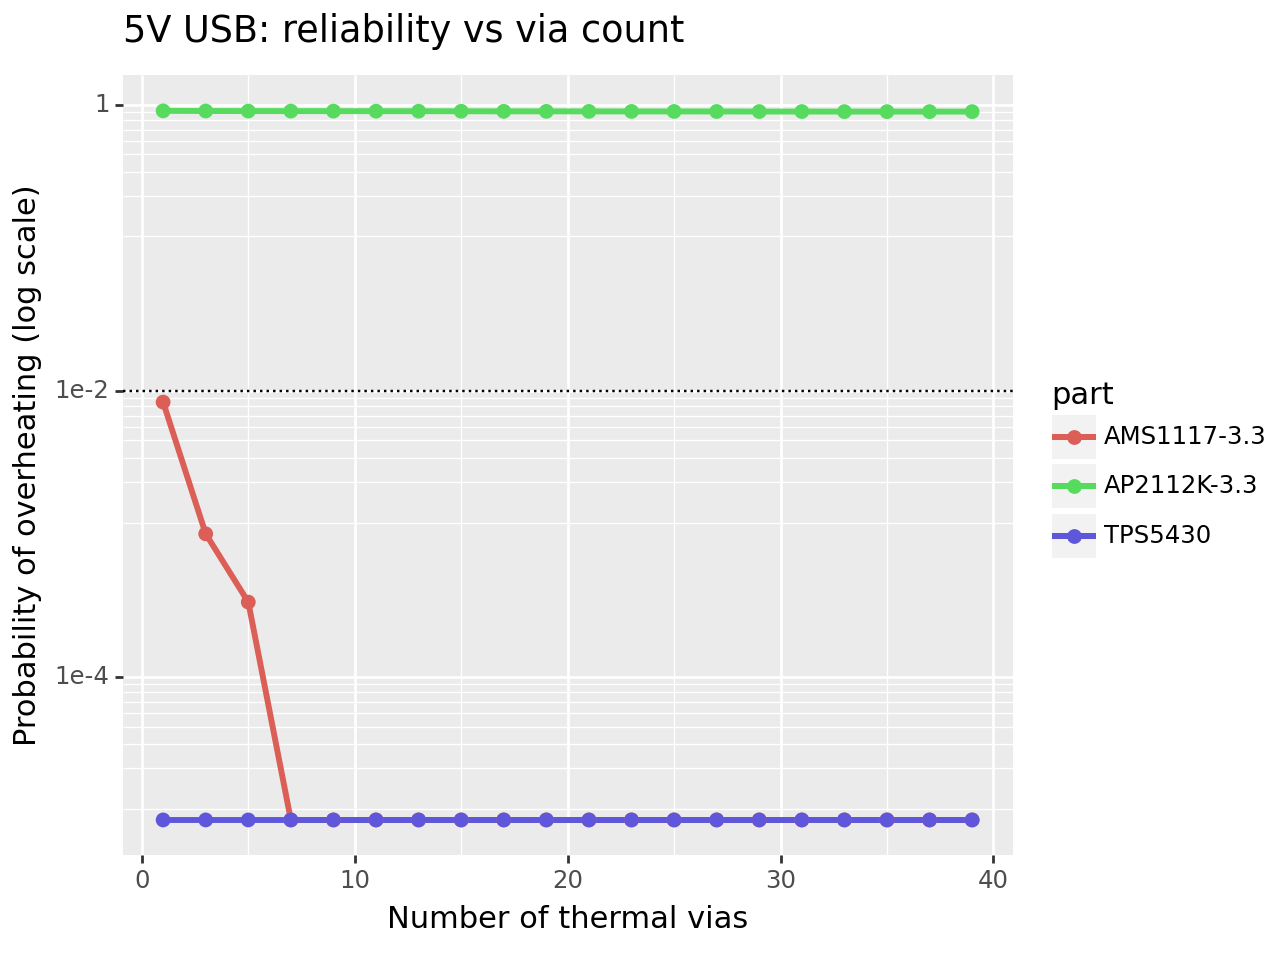

<Figure Size: (640 x 480)>

In [7]:
V_IN_SCENARIO_1_V = 5.0
via_count_sweep = list(range(1, 41, 2))

sweep_rows_scen1 = []
for regulator in ALL_REGULATORS:
    reliability_model = build_reliability_model(regulator, V_IN_SCENARIO_1_V)
    for n_vias in via_count_sweep:
        pof = estimate_prob_of_overheat(reliability_model, n_vias,
                                         regulator["Tj_max_C"])
        sweep_rows_scen1.append({
            "part": regulator["name"],
            "n_vias": n_vias,
            "pof": pof,
        })
df_sweep_scenario_1 = pd.DataFrame(sweep_rows_scen1)
df_sweep_scenario_1["pof_for_log_plot"] = np.maximum(df_sweep_scenario_1["pof"], 1e-5)

(df_sweep_scenario_1
 >> gr.ggplot(gr.aes("n_vias", "pof_for_log_plot", color="part"))
 + gr.geom_line(size=1.2)
 + gr.geom_point(size=2)
 + gr.geom_hline(yintercept=RELIABILITY_TARGET, linetype="dotted")
 + gr.scale_y_log10()
 + gr.labs(x="Number of thermal vias",
           y="Probability of overheating (log scale)",
           title="5V USB: reliability vs via count"))

### 5.1.2 Minimum feasible via count

In [8]:
min_vias_rows_scen1 = []
for regulator in ALL_REGULATORS:
    reliability_model = build_reliability_model(regulator, V_IN_SCENARIO_1_V)
    n_min = find_minimum_feasible_via_count(reliability_model,
                                             regulator["Tj_max_C"])
    min_vias_rows_scen1.append({
        "part":     regulator["name"],
        "n_min":    n_min if n_min is not None else "INFEASIBLE",
        "cost_usd": regulator["cost_usd"],
    })
df_min_vias_scenario_1 = pd.DataFrame(min_vias_rows_scen1)
df_min_vias_scenario_1

,part,n_min,cost_usd
0,AP2112K-3.3,INFEASIBLE,0.20
1,AMS1117-3.3,1,0.05
2,TPS5430,1,3.50


**Observation:** AP2112 is infeasible at any N. AMS1117 is feasible at a small N. TPS5430 is trivially feasible. AMS1117 is by far the cheapest feasible option.

### 5.1.3 Multi-start optimization (validation)

Method validation: ten restarts on a deterministic proxy problem, demonstrating that the problem is unimodal and the optimizer converges robustly. We use AMS1117 at 5V because it's a feasible case; restarts on an infeasible case would simply all hit the upper bound, which would not demonstrate convergence behavior.

In [9]:
regulator_for_restart_demo = regulator_AMS1117_classic_LDO

def restart_demo_function(df):
    T_j_nominal = compute_junction_temperature_C(
        n_vias=df.N,
        plating_thickness_um=VIA_PLATING_NOMINAL_UM,
        I_load_A=LOAD_CURRENT_NOMINAL_A,
        T_ambient_C=AMBIENT_TEMP_MEAN_C,
        V_in=V_IN_SCENARIO_1_V,
        regulator=regulator_for_restart_demo,
    )
    return gr.df_make(Tj_nominal=T_j_nominal, n_vias_output=df.N)

restart_demo_model = (
    gr.Model("Restart demo")
    >> gr.cp_vec_function(
        fun=restart_demo_function,
        var=["N"],
        out=["Tj_nominal", "n_vias_output"],
    )
    >> gr.cp_vec_function(
        fun=lambda df: gr.df_make(
            temp_constraint=df.Tj_nominal - regulator_for_restart_demo["Tj_max_C"]),
        var=["Tj_nominal"],
        out=["temp_constraint"],
    )
    >> gr.cp_bounds(N=(1, 50))
)
df_restart_results = gr.eval_min(
    restart_demo_model,
    out_min="n_vias_output",
    out_leq=["temp_constraint"],
    n_restart=10,
    seed=101,
)
df_restart_results[["N_0", "n_vias_output", "temp_constraint", "success"]].head(10)

Estimated runtime: 0.0000 sec
Estimated runtime: 0.0000 sec


,N_0,n_vias_output,temp_constraint,success
0,25.500000,1.0,-35.671435,True
1,26.303533,1.0,-35.671435,True
2,28.962712,1.0,-35.671435,True
3,2.395237,1.0,-35.671435,True
4,9.404561,1.0,-35.671435,True
5,34.578572,1.0,-35.671435,True
6,41.860946,1.0,-35.671435,True
7,16.041345,1.0,-35.671435,True
8,44.787041,1.0,-35.671435,True
9,36.355649,1.0,-35.671435,True


**Observation:** All 10 restarts converge to N=1 (the lower bound, since AMS1117 at 5V has plenty of margin). Convergence from 10 random initial points provides empirical support that this is the global minimum within the feasible range, but strong evidence for a smooth problem like this. `success=True` across all restarts confirms no line-search or constraint-handling failures.

## 5.2 Scenario 2: 12V adapter (Vin = 12V → 3.3V, 500 mA)

Voltage drop = 8.7V; LDO dissipation = 4.35W. Severe thermal stress.

### 5.2.1 Reliability vs via count

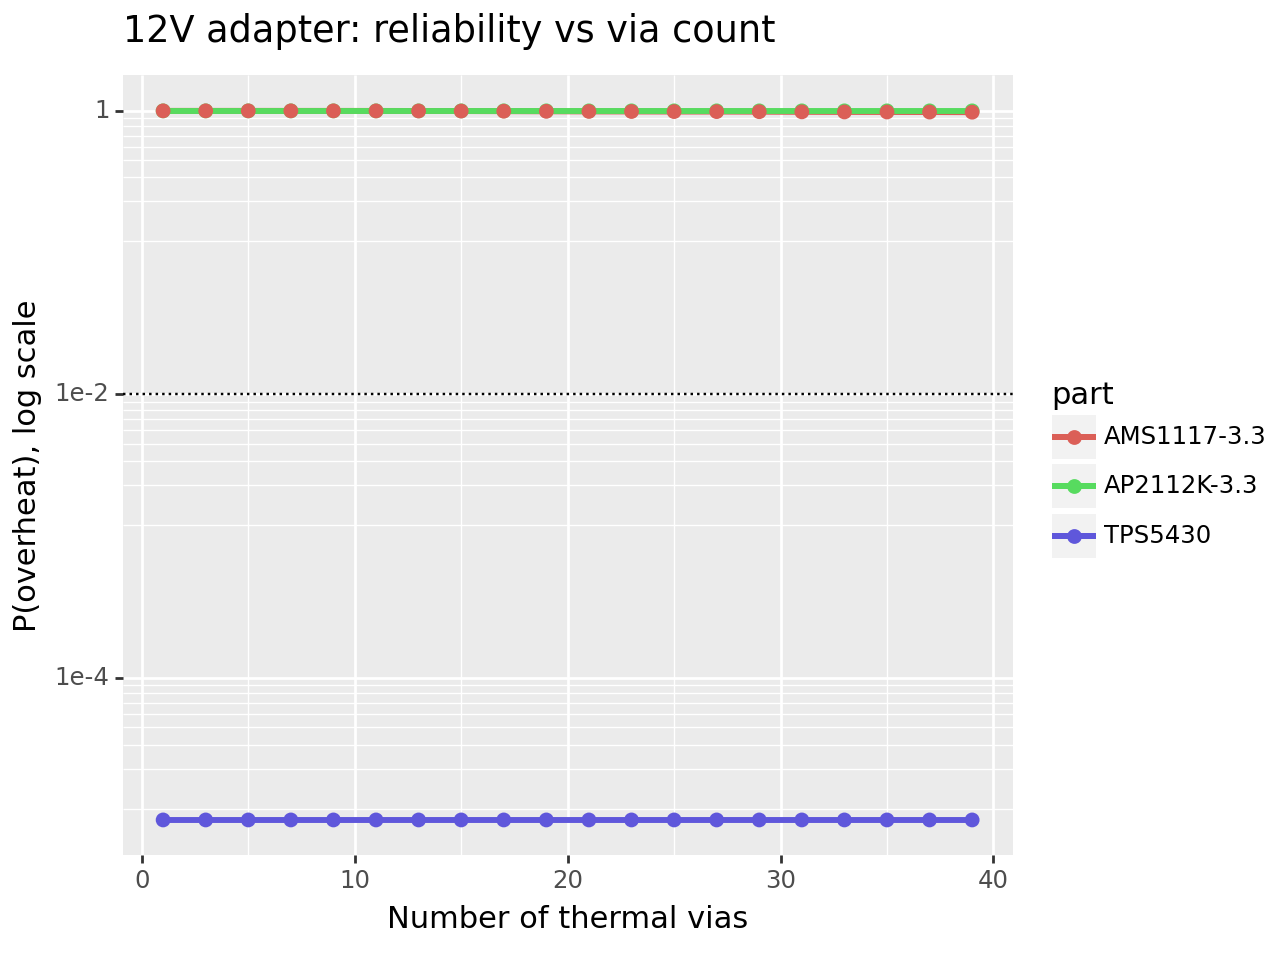

<Figure Size: (640 x 480)>

In [10]:
V_IN_SCENARIO_2_V = 12.0

sweep_rows_scen2 = []
for regulator in ALL_REGULATORS:
    reliability_model = build_reliability_model(regulator, V_IN_SCENARIO_2_V)
    for n_vias in via_count_sweep:
        pof = estimate_prob_of_overheat(reliability_model, n_vias, regulator["Tj_max_C"])
        sweep_rows_scen2.append({"part": regulator["name"], "n_vias": n_vias, "pof": pof})
df_sweep_scenario_2 = pd.DataFrame(sweep_rows_scen2)
df_sweep_scenario_2["pof_for_log_plot"] = np.maximum(df_sweep_scenario_2["pof"], 1e-5)

(df_sweep_scenario_2
 >> gr.ggplot(gr.aes("n_vias", "pof_for_log_plot", color="part"))
 + gr.geom_line(size=1.2) + gr.geom_point(size=2)
 + gr.geom_hline(yintercept=RELIABILITY_TARGET, linetype="dotted")
 + gr.scale_y_log10()
 + gr.labs(x="Number of thermal vias", y="P(overheat), log scale",
           title="12V adapter: reliability vs via count"))

### 5.2.2 Minimum feasible via count

In [11]:
min_vias_rows_scen2 = []
for regulator in ALL_REGULATORS:
    reliability_model = build_reliability_model(regulator, V_IN_SCENARIO_2_V)
    n_min = find_minimum_feasible_via_count(reliability_model, regulator["Tj_max_C"])
    min_vias_rows_scen2.append({
        "part":     regulator["name"],
        "n_min":    n_min if n_min is not None else "INFEASIBLE",
        "cost_usd": regulator["cost_usd"],
    })
pd.DataFrame(min_vias_rows_scen2)

,part,n_min,cost_usd
0,AP2112K-3.3,INFEASIBLE,0.20
1,AMS1117-3.3,INFEASIBLE,0.05
2,TPS5430,1,3.50


**Observation:** Both LDOs are infeasible at 12V. The 4.35 W dissipation exceeds their package ratings, and no via count saves them.

## 5.3 Combined results

### 5.3.1 Headline table

In [12]:
headline_rows = []
for regulator in ALL_REGULATORS:
    for V_in, scen in [(V_IN_SCENARIO_1_V, "5V USB"), (V_IN_SCENARIO_2_V, "12V adapter")]:
        rm = build_reliability_model(regulator, V_in)
        n_min = find_minimum_feasible_via_count(rm, regulator["Tj_max_C"])
        headline_rows.append({
            "part": regulator["name"], "scenario": scen,
            "n_min": n_min if n_min is not None else "INFEASIBLE",
            "cost_usd": regulator["cost_usd"],
        })
df_headline = pd.DataFrame(headline_rows)
df_headline

,part,scenario,n_min,cost_usd
0,AP2112K-3.3,5V USB,INFEASIBLE,0.20
1,AP2112K-3.3,12V adapter,INFEASIBLE,0.20
2,AMS1117-3.3,5V USB,1,0.05
3,AMS1117-3.3,12V adapter,INFEASIBLE,0.05
4,TPS5430,5V USB,1,3.50
5,TPS5430,12V adapter,1,3.50


### 5.3.2 Cost vs reliability (three-objective view)

Each point is one (regulator, scenario) at its minimum feasible N. Lower-left is better. Infeasible cases plotted at P=1.

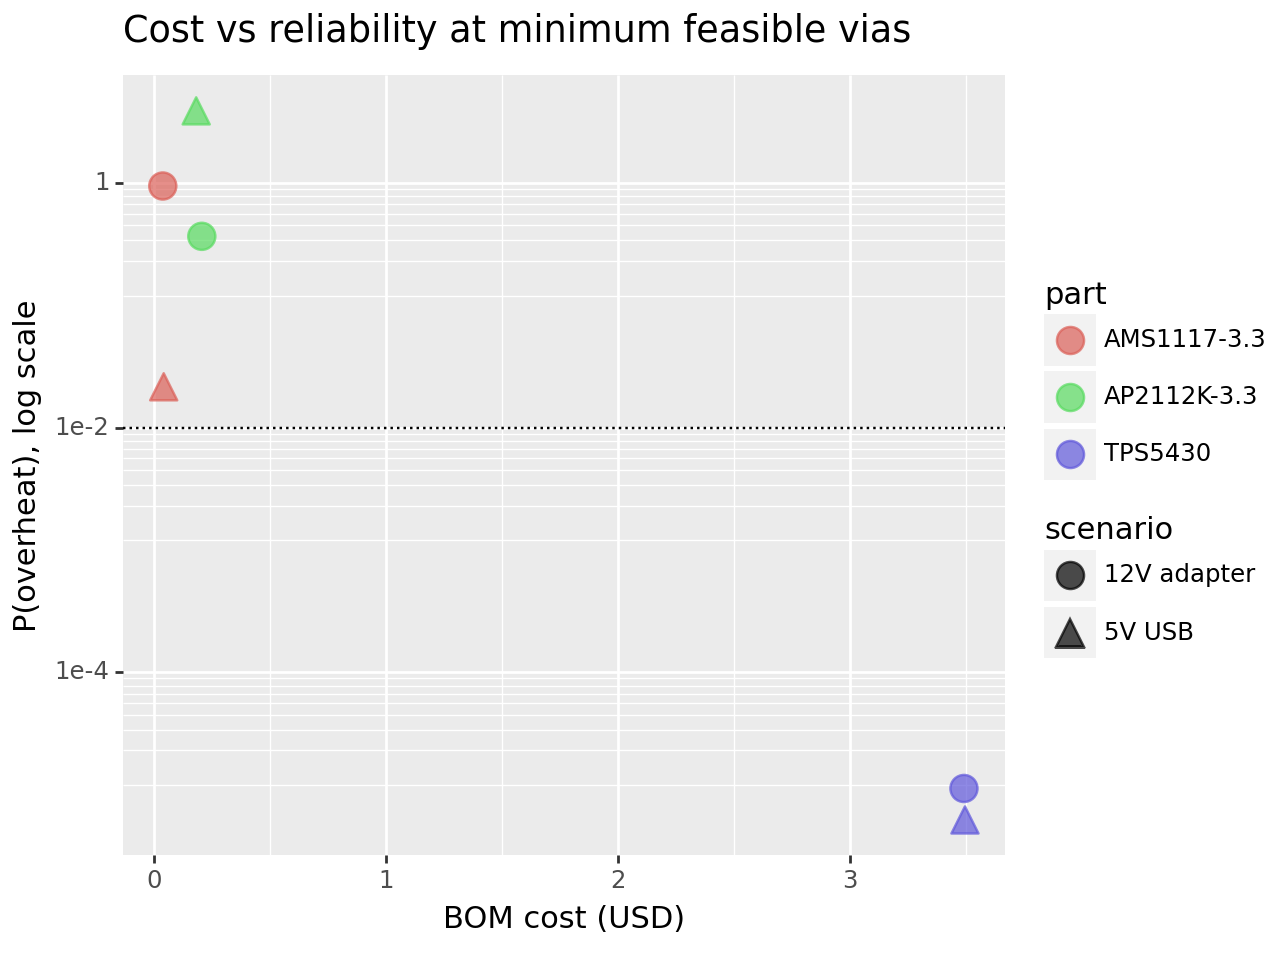

<Figure Size: (640 x 480)>

In [13]:
rows = []
for _, r in df_headline.iterrows():
    reg = [x for x in ALL_REGULATORS if x["name"] == r["part"]][0]
    V_in = V_IN_SCENARIO_1_V if r["scenario"] == "5V USB" else V_IN_SCENARIO_2_V
    if r["n_min"] == "INFEASIBLE":
        pof = 1.0
    else:
        rm = build_reliability_model(reg, V_in)
        pof = estimate_prob_of_overheat(rm, r["n_min"], reg["Tj_max_C"], n_samples=10000)
    rows.append({"part": r["part"], "scenario": r["scenario"],
                 "cost_usd": r["cost_usd"], "pof": max(pof, 1e-5)})
df_cost = pd.DataFrame(rows)

(df_cost
 >> gr.ggplot(gr.aes("cost_usd", "pof", color="part", shape="scenario"))
 + gr.geom_point(size=5, alpha=0.7, position="jitter")
 + gr.geom_hline(yintercept=RELIABILITY_TARGET, linetype="dotted")
 + gr.scale_y_log10()
 + gr.labs(x="BOM cost (USD)", y="P(overheat), log scale",
           title="Cost vs reliability at minimum feasible vias"))

**Observation:** At 5V, AMS1117 is feasible AND ~70× cheaper than TPS5430 (cost-optimal). At 12V, both LDOs sit above the 1% line (infeasible at any cost), so TPS5430 is the only option.

### 5.3.3 Uncertainty sensitivity

Perturb each uncertainty in the "worse" direction; the largest delta identifies the dominant source.

In [14]:
def sensitivity(reg, V_in, N, n=2000):
    def build(I_mult=1.0, T_shift=0.0, t_shift=0.0):
        def fn(df): return gr.df_make(Tj=compute_junction_temperature_C(
            df.N, df.t_plate, df.I_load, df.T_amb, V_in, reg))
        return (gr.Model() >> gr.cp_vec_function(fun=fn,
                var=["N","I_load","T_amb","t_plate"], out=["Tj"])
            >> gr.cp_bounds(N=(1,50))
            >> gr.cp_marginals(
                I_load=dict(dist="lognorm", s=LOAD_CURRENT_COV, loc=0.0,
                            scale=LOAD_CURRENT_NOMINAL_A * I_mult),
                T_amb=dict(dist="norm", loc=AMBIENT_TEMP_MEAN_C + T_shift,
                           scale=AMBIENT_TEMP_STD_C),
                t_plate=dict(dist="norm", loc=VIA_PLATING_NOMINAL_UM + t_shift,
                             scale=VIA_PLATING_STD_UM))
            >> gr.cp_copula_independence())
    pof = lambda m: estimate_prob_of_overheat(m, N, reg["Tj_max_C"], n_samples=n)
    base = pof(build())
    return {"part": reg["name"], "N": N,
            "baseline": round(base, 4),
            "Δ load +20%":   round(pof(build(I_mult=1.2)) - base, 4),
            "Δ amb +5°C":    round(pof(build(T_shift=5.0)) - base, 4),
            "Δ plate -3μm":  round(pof(build(t_shift=-3.0)) - base, 4)}

sens = []
for _, r in df_headline.iterrows():
    if r["n_min"] == "INFEASIBLE": continue
    reg = [x for x in ALL_REGULATORS if x["name"] == r["part"]][0]
    V_in = V_IN_SCENARIO_1_V if r["scenario"] == "5V USB" else V_IN_SCENARIO_2_V
    row = sensitivity(reg, V_in, r["n_min"]); row["scenario"] = r["scenario"]
    sens.append(row)
pd.DataFrame(sens)

,part,N,baseline,Δ load +20%,Δ amb +5°C,Δ plate -3μm,scenario
0,AMS1117-3.3,1,0.0065,0.0735,0.011,0.003,5V USB
1,TPS5430,1,0.0000,0.0000,0.000,0.000,5V USB
2,TPS5430,1,0.0000,0.0000,0.000,0.000,12V adapter


**Observation:** Load current dominates because dissipated power scales linearly with`I_load`. Products with bursty load profiles should size vias for an upper-quantile load, not the average.

### 5.3.4 Robustness of `theta_CA_base` for AMS1117

The most uncertain modeling parameter. Test three values to see if the recommendation holds.

In [15]:
robust = []
for theta, label in [(47.0, "optimistic"), (68.0, "baseline"), (90.0, "pessimistic")]:
    reg = dict(regulator_AMS1117_classic_LDO); reg["theta_CA_base_CperW"] = theta
    rm = build_reliability_model(reg, V_IN_SCENARIO_1_V)
    n_min = find_minimum_feasible_via_count(rm, reg["Tj_max_C"])
    Tj1 = compute_junction_temperature_C(1, VIA_PLATING_NOMINAL_UM,
        LOAD_CURRENT_NOMINAL_A, AMBIENT_TEMP_MEAN_C, V_IN_SCENARIO_1_V, reg)
    robust.append({"assumption": label, "theta_CA_base": theta,
                   "Tj_at_N=1": round(Tj1, 1),
                   "n_min_5V": n_min if n_min else "INFEASIBLE"})
pd.DataFrame(robust)

,assumption,theta_CA_base,Tj_at_N=1,n_min_5V
0,optimistic,47.0,76.9,1
1,baseline,68.0,89.3,1
2,pessimistic,90.0,101.0,3


**Observation:** AMS1117 at 5V needs N=1–3 across the range such that it is narrow enough that the recommendation is robust, but designers using minimal copper should plan for the high end.

## 5.4 Results in light of model limitations

The recommendations above hold under the model's assumptions. Each limitation from Section 3.4 maps to a specific way the system may behave differently in reality, with consequences for stakeholders:

- **L1 (no transients):** Bursty current loads can briefly spike T_j above predictions. The hardware engineer should add margin for products with high peak-to-average load ratios; otherwise end users see intermittent thermal shutdowns.
- **L2 (single component):** Adjacent heat sources raise local ambient. The recommended N is a *lower bound* for densely packed boards; otherwise end users see seasonal failures (hot months, poor ventilation).
- **L3 (no copper pour modeling):** The robustness analysis (5.3.4) shows N=1–3 across copper-pour assumptions for AMS1117. Conservative designers should pick the high end, protecting end users from layout-dependent failures.
- **L4 (fixed switcher efficiency):** TPS5430 predictions are approximate at extreme operating points. Engineers designing for unusual duty cycles should re-run with operating-point efficiency.

**Net:** The engineer's needs (defensible N, low cost, low area) are well served. The end user's needs (reliability, lifetime, safety) are conditionally served, with the conditions being these four limitations.

# 6. Conclusion

## 6.1 Summary

This project replaces a common engineering guess (how many thermal vias under my voltage regulator?) with a probabilistic, datasheet-grounded recommendation that accounts for variation in load, ambient, and via plating tolerance. For a 3.3V/500 mA rail: at **5V**, AMS1117 with **1 to 3 vias** is the cost-optimal feasible choice (about \$0.05); at **12V**, both LDOs are infeasible regardless of N, leaving TPS5430 (about \$3.50) as the only viable option. The general rule: for input-output drops above 3V at meaningful current, switch topologies rather than fight thermal margin with vias. This serves the hardware engineer's need for a defensible via count without copying a reference layout, and protects end users from the intermittent faults, shortened lifetime, and e-waste caused by under-via'd designs.

## 6.2 Ethical practice

My core engineering values are **honesty about uncertainty**, **service to end users**, and **humility about model limits**. Each shaped specific decisions:

- **Technomoral humility** (course concept). The Tenchi Diagram lists four assumptions and four matching limitations; Section 5.4 carries those forward into the results so a reader cannot mistake recommendations for guarantees. The robustness analysis in 5.3.4 actively tests the most uncertain parameter rather than hiding it.

- **Skeptical reverence** (course concept). I treat datasheet thermal resistances with reverence (they are the manufacturer's calibrated commitment) but with skepticism: they assume reference layouts that may not match a real design. The empirical `via_effectiveness` constants and the hand-calc verification in 5.0 are admissions of what I cannot derive from first principles in two weeks.

- **Honesty about uncertainty.** Industry practice for via count is a rule-of-thumb guess. By modeling the three uncertainties explicitly and reporting probabilities of overheating, this project says: a designer should *know* the failure probability they are committing to.

- **Service to end users.** Naming end users as a stakeholder forces externalized costs (warranty returns, e-waste, intermittent failures) into the formulation. Setting α = 0.01 is an explicit value judgment, not a hidden default. A designer could change it for medical (α = 0.001) or disposable (α = 0.05) products, and the choice would be visible.

- **Infeasibility reported, not engineered away.** Three of six cases came back infeasible. A less honest practice would loosen alpha until the design "works." Reporting infeasibility clearly protects downstream designers from inheriting a marginal design.